In [21]:
# Apply a visual "Quant" style
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.io as pio

plt.style.use('dark_background')
sns.set_context("talk")
custom_params = {"axes.spines.right": False, "axes.spines.top": False, "grid.alpha": 0.1}
sns.set_theme(style="darkgrid", rc=custom_params)

pio.templates.default = "plotly_dark"

In [22]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from datetime import datetime, timedelta

# 1. Retrieve S&P 500 Tickers from Wikipedia
print("Fetching S&P 500 ticker list...")
url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'

# Use a User-Agent header
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36"
}

try:
    response = requests.get(url, headers=headers)
    # Use pandas to read the HTML content from the response text
    table = pd.read_html(response.text)
    sp500_df = table[0]
    tickers = sp500_df['Symbol'].tolist()
    print(f"Successfully retrieved {len(tickers)} tickers.")
except Exception as e:
    print(f"Error fetching tickers: {e}")
    # Fallback: A tiny subset in case Wikipedia is completely unreachable
    tickers = tickers = [
    'AAPL', 'MSFT', 'NVDA', 'AMD', 'GOOG', 'META', # Big Tech
    'JPM', 'BAC', 'GS', 'MS', 'WFC', # Banks
    'XOM', 'CVX', 'COP', 'SLB', # Energy
    'JNJ', 'PFE', 'MRK', 'LLY', # Pharma
    'KO', 'PEP', 'PG', 'WMT', 'COST', # Consumer Staples
    'BA', 'CAT', 'LMT', # Industrial
    'NEE', 'DUK' # Utilities
]
    
# Yahoo Finance uses '-' instead of '.' for tickers like BRK.B
tickers = [t.replace('.', '-') for t in tickers]

# 2. Download 5 Years of Historical Data
# We focus only on 'Adj Close' to account for dividends and splits.
print(f"Downloading data for {len(tickers)} tickers. This may take a moment...")
end_date = datetime.now()
start_date = end_date - timedelta(days=5*365)

# Downloading the full universe
raw_data = yf.download(tickers, start=start_date, end=end_date, interval='1d')['Close']

Fetching S&P 500 ticker list...


/var/folders/gt/gf9mfwm14m9g9tmprjhzcvc80000gn/T/ipykernel_6648/3801613004.py:20: FutureWarning:

Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.



Successfully retrieved 503 tickers.


[*********************100%***********************]  503 of 503 completed


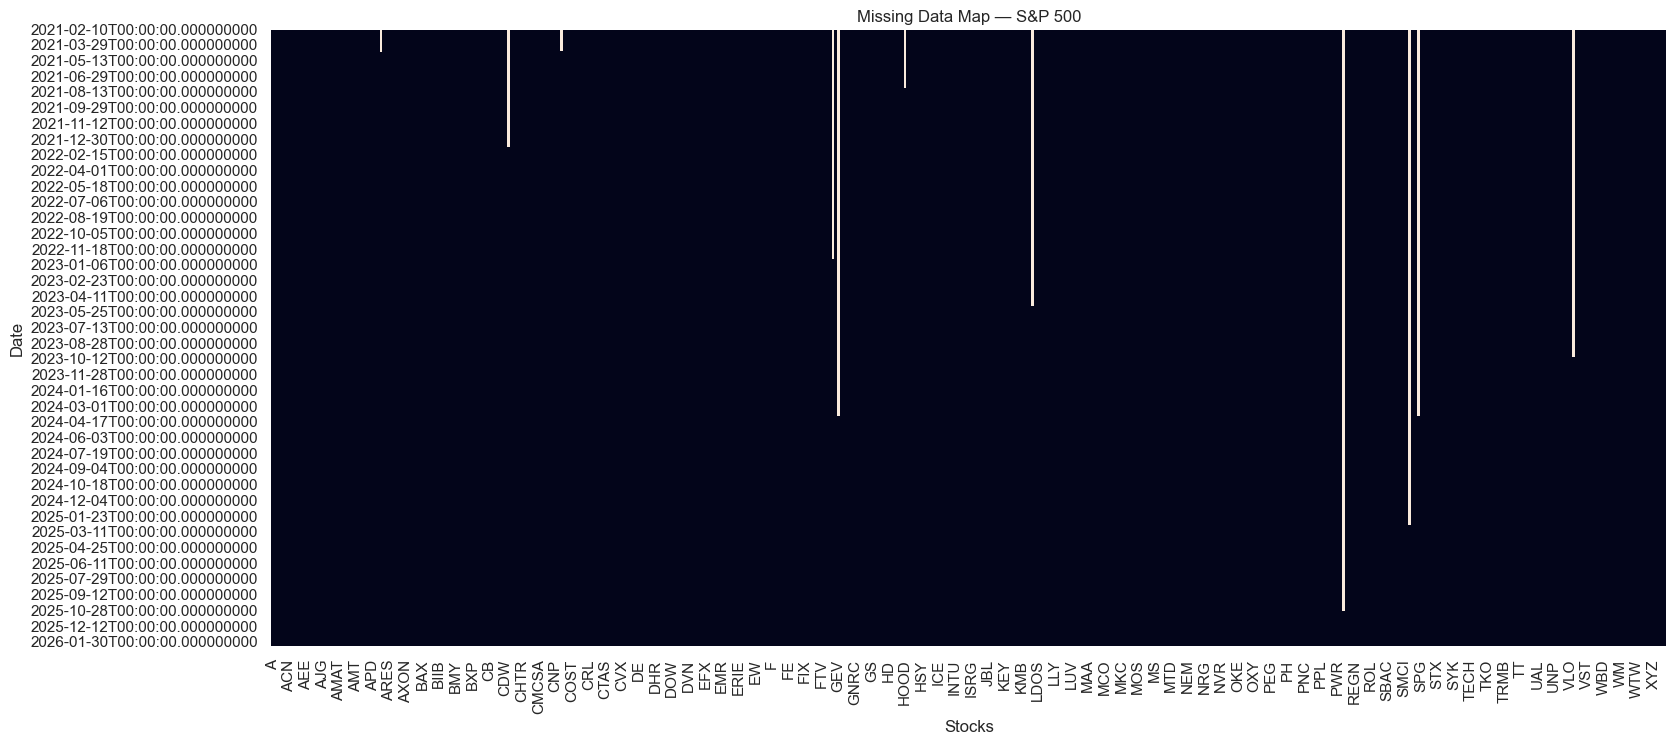

In [23]:
plt.figure(figsize=(18,8))
sns.heatmap(raw_data.isna(), cbar=False)
plt.title("Missing Data Map — S&P 500")
plt.xlabel("Stocks")
plt.ylabel("Date")
plt.show()

In [24]:
# Remove stocks with too much missing data
threshold = int(len(raw_data) * 0.8)

clean_data = raw_data.dropna(axis=1, thresh=threshold)

# Forward-fill remaining gaps
clean_data = clean_data.fillna(method="ffill")

print("Original shape:", raw_data.shape)
print("Clean shape:", clean_data.shape)

Original shape: (1255, 503)
Clean shape: (1255, 496)


/var/folders/gt/gf9mfwm14m9g9tmprjhzcvc80000gn/T/ipykernel_6648/3437352821.py:7: FutureWarning:

DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.



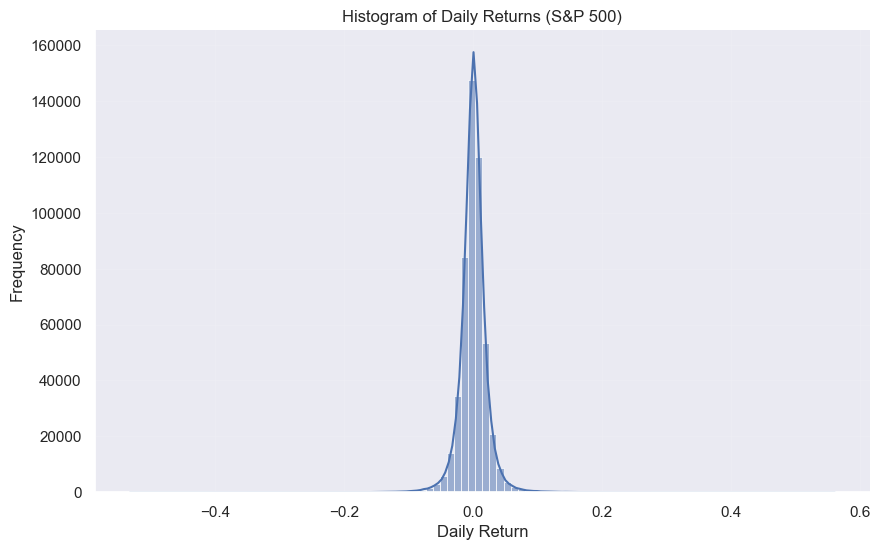

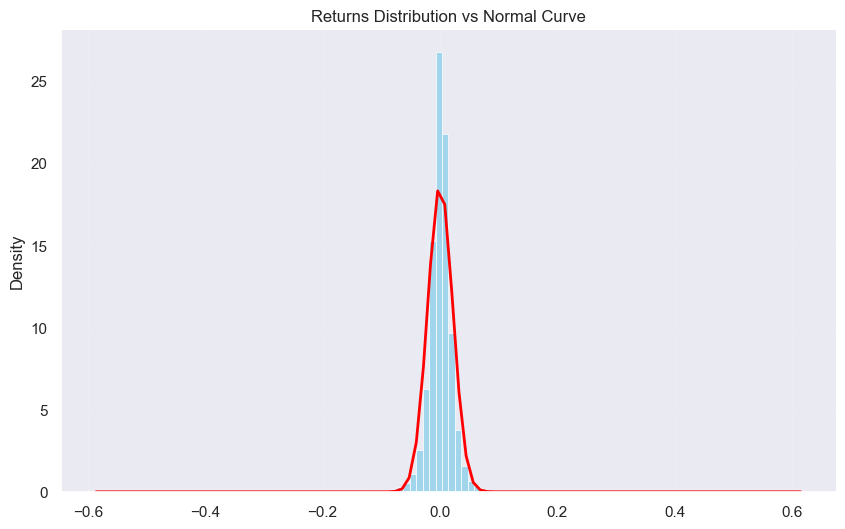

In [25]:
returns = clean_data.pct_change().dropna()
returns.head()

returns = clean_data.pct_change().dropna()

plt.figure(figsize=(10,6))

# Flatten all stock returns into one array
all_returns = returns.values.flatten()

# Plot histogram
sns.histplot(all_returns, bins=100, kde=True)

plt.title("Histogram of Daily Returns (S&P 500)")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.show()

from scipy.stats import norm
import numpy as np

plt.figure(figsize=(10,6))

sns.histplot(all_returns, bins=100, stat="density", color="skyblue")

mu, std = norm.fit(all_returns)
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)

plt.plot(x, p, 'red', linewidth=2)

plt.title("Returns Distribution vs Normal Curve")
plt.show()

/Users/daphne/Desktop/stock_analysis/venv/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning:

Clustering large matrix with scipy. Installing `fastcluster` may give better performance.

/Users/daphne/Desktop/stock_analysis/venv/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning:

Clustering large matrix with scipy. Installing `fastcluster` may give better performance.



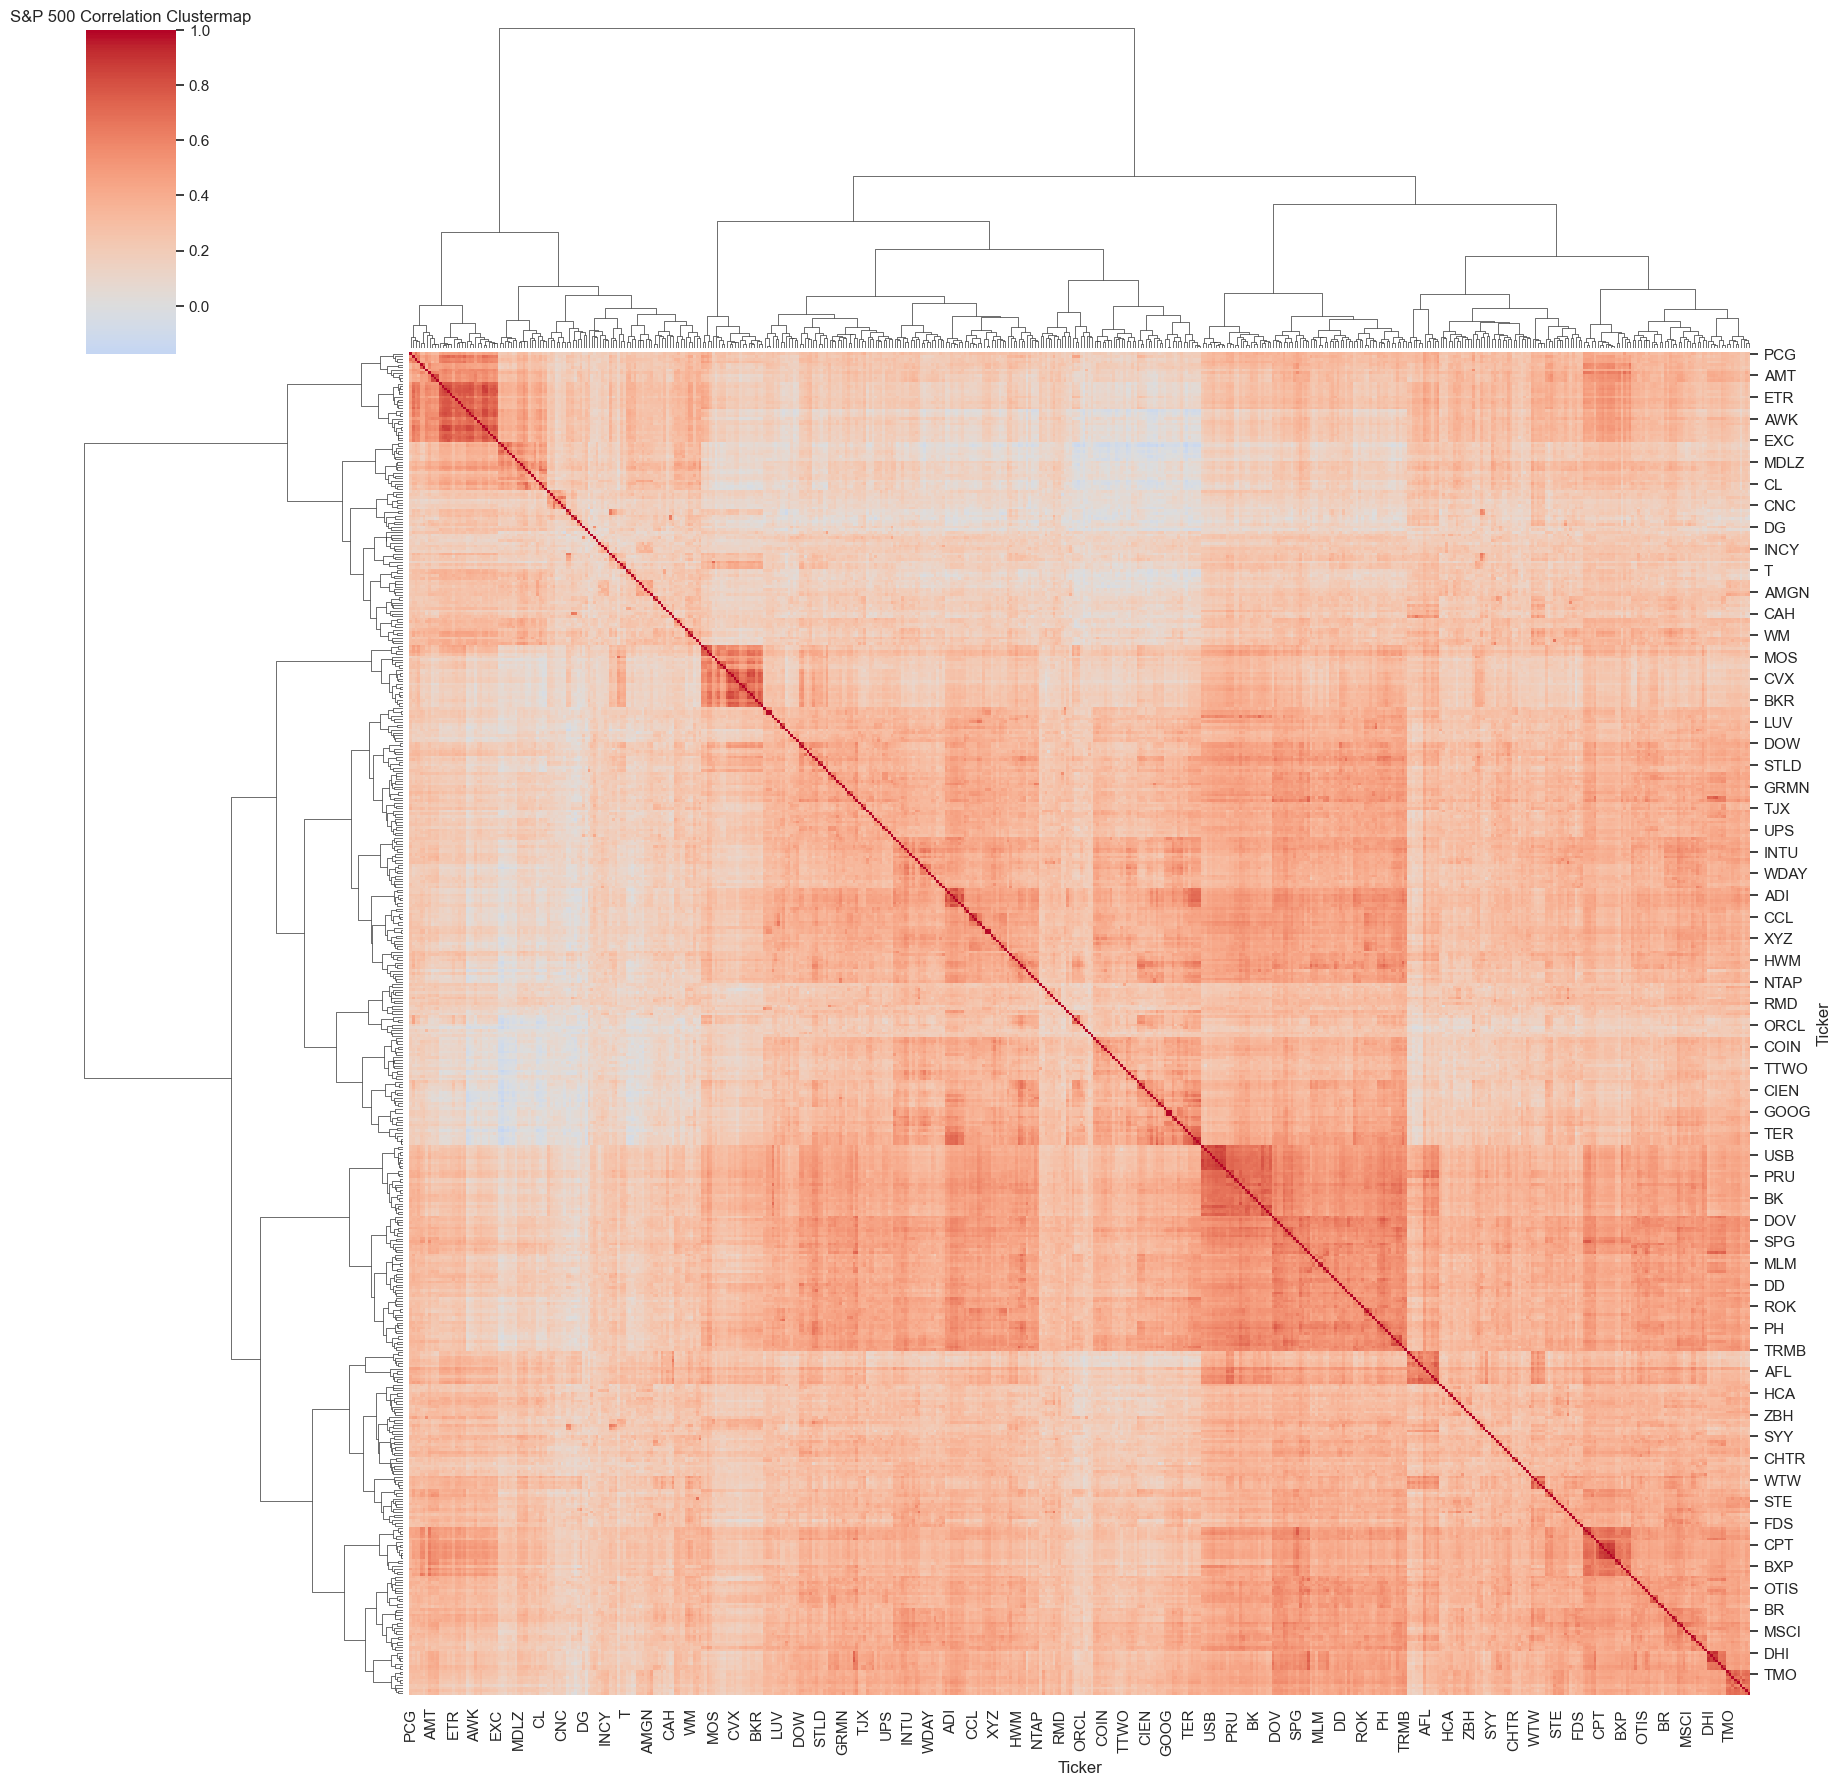

In [26]:
sns.clustermap(
    returns.corr(),
    cmap="coolwarm",
    center=0,
    method="ward",
    figsize=(18,18)
)

plt.title("S&P 500 Correlation Clustermap")
plt.show()

In [27]:
corr = returns.corr()

pairs = corr.unstack().sort_values()

print(pairs.head(10))

Ticker  Ticker
GIS     NVDA     -0.175295
NVDA    GIS      -0.175295
CRWD    GIS      -0.158006
GIS     CRWD     -0.158006
        MU       -0.156003
MU      GIS      -0.156003
GIS     WDC      -0.149802
WDC     GIS      -0.149802
GIS     SMCI     -0.145438
SMCI    GIS      -0.145438
dtype: float64


Most anti-correlated pair: GIS and NVDA


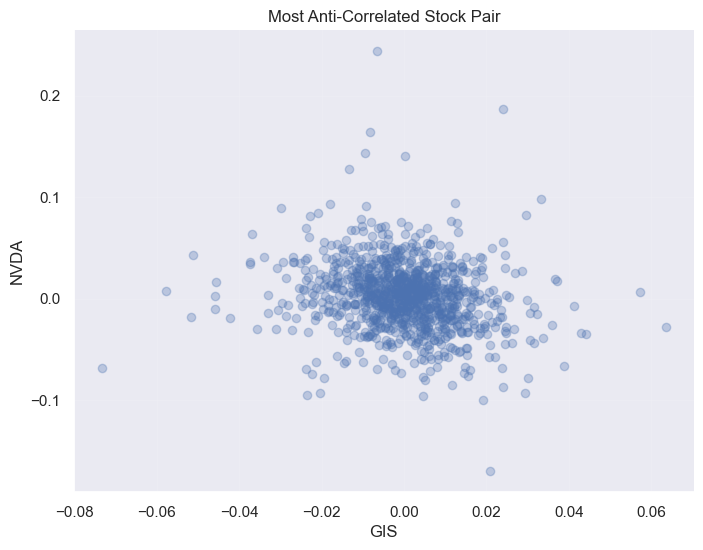

In [28]:
# Get most negative correlated pair
stock_a, stock_b = pairs.index[0]

print("Most anti-correlated pair:", stock_a, "and", stock_b)

plt.figure(figsize=(8,6))
plt.scatter(returns[stock_a], returns[stock_b], alpha=0.3)

plt.xlabel(stock_a)
plt.ylabel(stock_b)
plt.title("Most Anti-Correlated Stock Pair")
plt.show()

In [29]:
from sklearn.preprocessing import StandardScaler

# Transpose so rows = stocks
returns_T = returns.T

# Normalize
scaled_data = StandardScaler().fit_transform(returns_T)

In [30]:
from sklearn.decomposition import PCA

pca = PCA()
pca.fit(scaled_data)

explained = pca.explained_variance_ratio_

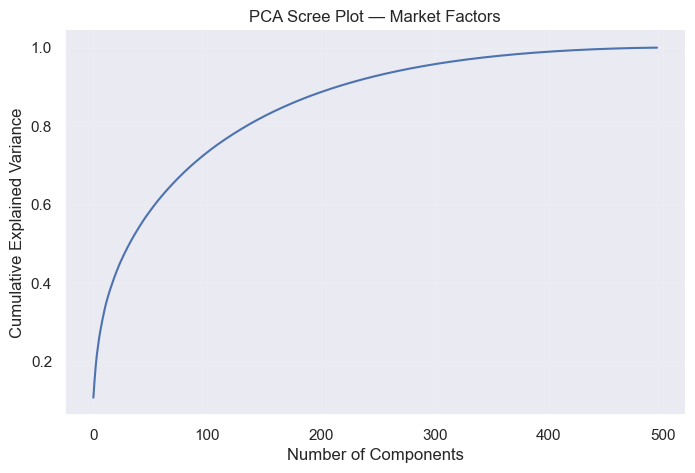

In [31]:
plt.figure(figsize=(8,5))
plt.plot(explained.cumsum())
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Scree Plot — Market Factors")
plt.show()

In [32]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
emb = tsne.fit_transform(scaled_data)

tsne_df = pd.DataFrame(emb, columns=["x","y"])
tsne_df["ticker"] = returns_T.index

/Users/daphne/Desktop/stock_analysis/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning:

divide by zero encountered in matmul

/Users/daphne/Desktop/stock_analysis/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning:

overflow encountered in matmul

/Users/daphne/Desktop/stock_analysis/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning:

invalid value encountered in matmul

/Users/daphne/Desktop/stock_analysis/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning:

divide by zero encountered in matmul

/Users/daphne/Desktop/stock_analysis/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning:

overflow encountered in matmul

/Users/daphne/Desktop/stock_analysis/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning:

invalid value encountered in matmul

/Users/daphne/Desktop/stock_analysis/venv/lib/python3.9/site-packages/sklearn/utils/

In [33]:
import plotly.express as px



In [34]:
# Map ticker → sector
sector_map = sp500_df.set_index("Symbol")["GICS Sector"].to_dict()

# Fix ticker format back (replace - with .)
tsne_df["sector"] = tsne_df["ticker"].apply(
    lambda x: sector_map.get(x.replace("-", "."))
)

fig = px.scatter(
    tsne_df,
    x="x",
    y="y",
    color="sector",
    hover_data=["ticker"],
    title="S&P 500 Market Map (t-SNE by Sector)"
)

fig.show()

In [35]:
import yfinance as yf

stock = "AAPL"

single_data = yf.download(stock, period="5y", auto_adjust=False)

[*********************100%***********************]  1 of 1 completed


In [36]:
print(single_data["Close"].describe())

Ticker         AAPL
count   1256.000000
mean     184.123774
std       40.244613
min      116.360001
25%      150.369995
50%      175.620003
75%      214.112503
max      286.190002


In [37]:
import yfinance as yf
import plotly.graph_objects as go

# Download Apple data fresh every time
stock = "AAPL"

single_data = yf.download(stock, period="5y", auto_adjust=False)

# Flatten columns if multi-index
if isinstance(single_data.columns, pd.MultiIndex):
    single_data.columns = single_data.columns.droplevel(1)

# Plot candlestick
fig = go.Figure(
    data=[go.Candlestick(
        x=single_data.index,
        open=single_data["Open"],
        high=single_data["High"],
        low=single_data["Low"],
        close=single_data["Close"]
    )]
)

fig.update_layout(
    title="Apple (AAPL) Candlestick — 5 Years",
    yaxis_title="Price ($)",
    height=600
)

fig.show()


[*********************100%***********************]  1 of 1 completed
